In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from XvP_utils.plotting import processing

PROJECT_DIR = Path('/home/mcaskey/10XvParse')

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
TECHS = ['10x', 'polyT', 'randO', 'parse']
COLORS = {
    '10x':   '#4C72B0',
    'polyT': '#DD8452',
    'randO': '#C44E52',
    'parse': '#55A868',
}
TECH_LABELS = {
    '10x':   '10X Genomics',
    'polyT': "Parse 3'",
    'randO': 'Parse Random Oligo',
    'parse': 'Parse (combined)',
}

In [4]:
SAMPLES = [
    {
        'label': 'A2',    'analysis': 'Analysis_2',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': 'standard',
        'malat1_gene': 'Malat1',
        'cutoffs': {'10x': 300, 'polyT': 300, 'randO': 300, 'parse': 300},
    },
    {
        'label': 'A2_mini',    'analysis': 'Analysis_2',
        'tenx_assay': '10x',    'parse_assay': 'parse_mini',
        'tenx_type': 'mini',
        'malat1_gene': 'Malat1',
        'cutoffs': {'10x': 300, 'polyT': 300, 'randO': 300, 'parse': 300},
    },
    {
        'label': 'A3_H1', 'analysis': 'Analysis_3',
        'tenx_assay': '10x_H1', 'parse_assay': 'parse_H1',
        'tenx_type': '',
        'malat1_gene': 'MALAT1',
        'cutoffs': {'10x': 100, 'polyT': 500, 'randO': 500, 'parse': 500},
    },
    {
        'label': 'A3_H2', 'analysis': 'Analysis_3',
        'tenx_assay': '10x_H2', 'parse_assay': 'parse_H2',
        'tenx_type': '',
        'malat1_gene': 'MALAT1',
        'cutoffs': {'10x': 150, 'polyT': 600, 'randO': 600, 'parse': 600},
    },
    {
        'label': 'A4',    'analysis': 'Analysis_4',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
        'malat1_gene': ['HUMAN_MALAT1', 'MOUSE_Malat1'],
        'cutoffs': {'10x': 75,  'polyT': 300, 'randO': 300, 'parse': 300},
    },
    {
        'label': 'A5',    'analysis': 'Analysis_5',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
        'malat1_gene': 'MALAT1',
        'cutoffs': {'10x': 75,  'polyT': 300, 'randO': 300, 'parse': 300},
    },
    {
        'label': 'A6',    'analysis': 'Analysis_6',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
        'malat1_gene': 'MALAT1',
        'cutoffs': {'10x': 300, 'polyT': 400, 'randO': 400, 'parse': 400},
    },
    {
        'label': 'A7',    'analysis': 'Analysis_7',
        'tenx_assay': '10x',    'parse_assay': 'parse',
        'tenx_type': '',
        'malat1_gene': 'MALAT1',
        'cutoffs': {'10x': 200, 'polyT': 600, 'randO': 600, 'parse': 600},
    },
]

In [5]:
def extract_cell_metrics(adata, malat1_gene):
    genes = malat1_gene if isinstance(malat1_gene, list) else [malat1_gene]
    genes_present = [g for g in genes if g in adata.var_names]
    if genes_present:
        malat1_counts = np.asarray(adata[:, genes_present].X.sum(axis=1)).flatten()
    else:
        malat1_counts = np.zeros(adata.n_obs)
    percent_malat1 = malat1_counts / adata.obs['n_counts'].values * 100

    return pd.DataFrame({
        'percent_nascent': adata.obs['percent_nascent'].values,
        'percent_malat1':  percent_malat1,
        'percent_ribo':    adata.obs['percent_ribo'].values,
        'percent_lnc':     adata.obs['percent_lnc'].values,
        'percent_pc':      adata.obs['percent_pc'].values,
    })


def load_sample(sample):
    label    = sample['label']
    analysis = sample['analysis']

    gene_info = pd.read_csv(
        PROJECT_DIR / 'Notebooks' / analysis / 'gene_data' / 'gene_attributes.csv',
        index_col=0
    )

    dfs, stat_rows = [], []
    for tech, data_name, assay, use_modified, tenx_type in [
        ('10x',   '10x',   sample['tenx_assay'],  False, sample['tenx_type']),
        ('polyT', 'polyT', sample['parse_assay'], False, ''),
        ('randO', 'randO', sample['parse_assay'], False, ''),
        ('parse', 'parse', sample['parse_assay'], True,  ''),
    ]:
        d = processing.init_processing(
            analysis_name=analysis, project_dir=PROJECT_DIR,
            data_name=data_name, assay=assay,
            data_title=f'{label} {tech}',
            type=tenx_type, modified=use_modified,
        )
        d = processing.refilter(d, min_counts=sample['cutoffs'][tech])
        processing.add_cell_metrics(d, gene_info)

        n_proc     = d.uns['n_processed']
        n_aligned  = d.uns['n_aligned']
        star_uniq  = d.uns['star_uniquely_mapped']
        star_multi = d.uns['star_multimapped']
        star_unmap = d.uns['star_unmapped']
        star_total = star_uniq + star_multi + star_unmap
        stat_rows.append({
            'sample': label,
            'tech':   tech,
            'kallisto_pct_unmapped': (n_proc - n_aligned) / n_proc * 100,
            'star_pct_unmapped':     star_unmap / star_total * 100,
            'star_pct_unique':       star_uniq  / star_total * 100,
        })

        df = extract_cell_metrics(d, sample['malat1_gene'])
        df['label']  = f"{label}\n{tech}"
        df['sample'] = label
        df['tech']   = tech
        dfs.append(df)
        del d

    return pd.concat(dfs, ignore_index=True), stat_rows

In [6]:
all_dfs, all_stats = [], []
for s in SAMPLES:
    print(f"Loading {s['label']}...")
    sample_df, sample_stats = load_sample(s)
    all_dfs.append(sample_df)
    all_stats.extend(sample_stats)

df = pd.concat(all_dfs, ignore_index=True)
stats_df = pd.DataFrame(all_stats)
print(f"Total cells: {len(df)}")

Loading A2...


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Loading A2_mini...


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Loading A3_H1...


...

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Loading A7...


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


Total cells: 415939


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


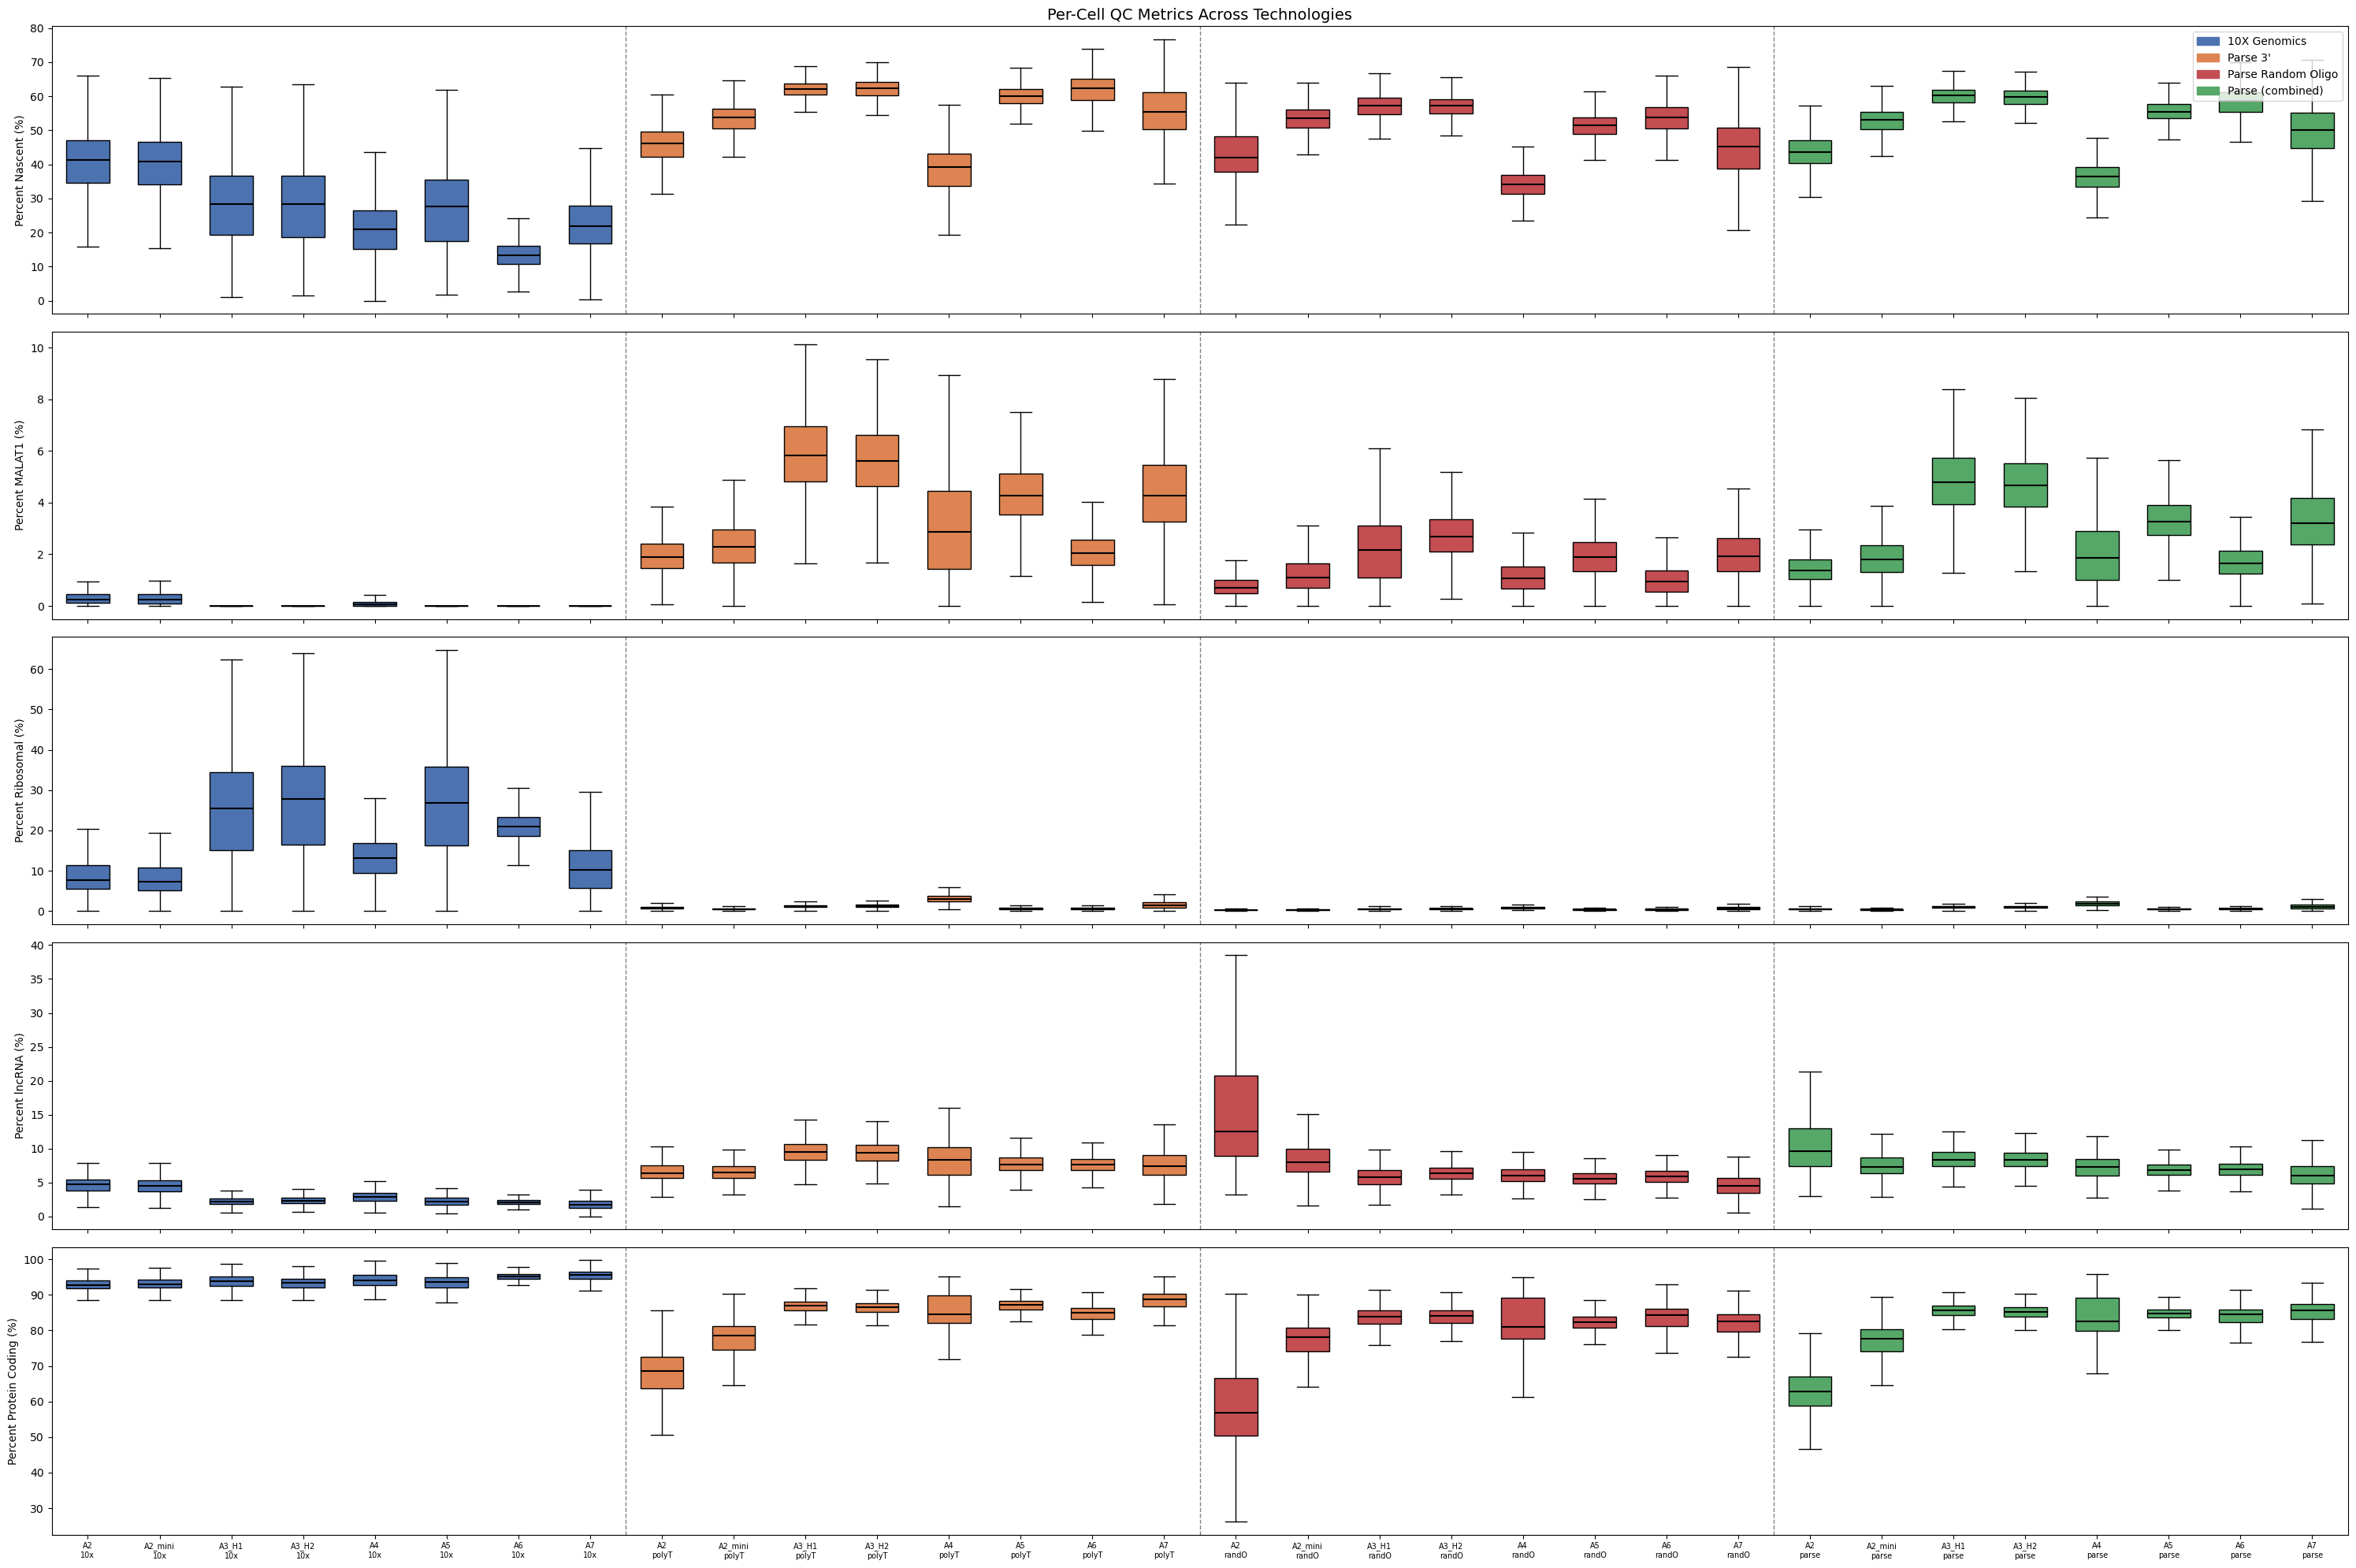

In [7]:
METRICS = [
    ('percent_nascent', 'Percent Nascent (%)'),
    ('percent_malat1',  'Percent MALAT1 (%)'),
    ('percent_ribo',    'Percent Ribosomal (%)'),
    ('percent_lnc',     'Percent lncRNA (%)'),
    ('percent_pc',      'Percent Protein Coding (%)'),
]

# Group by technology: all samples for each tech together, 10x leftmost
n_samples = len(SAMPLES)
x_order = [f"{s['label']}\n{tech}" for tech in TECHS for s in SAMPLES]

fig, axes = plt.subplots(len(METRICS), 1, figsize=(30, 4 * len(METRICS)), sharex=True)

for ax, (metric, ylabel) in zip(axes, METRICS):
    data_by_label = [df.loc[df['label'] == lbl, metric].dropna().values for lbl in x_order]
    bp = ax.boxplot(
        data_by_label,
        positions=range(len(x_order)),
        patch_artist=True,
        showfliers=False,
        widths=0.6,
        medianprops=dict(color='black', linewidth=1.5),
    )
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(COLORS[TECHS[i // n_samples]])

    for t in range(1, len(TECHS)):
        ax.axvline(x=t * n_samples - 0.5, color='gray', linestyle='--', linewidth=1)

    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(x_order)))
    ax.set_xticklabels(x_order, fontsize=7)

legend_handles = [mpatches.Patch(color=COLORS[t], label=TECH_LABELS[t]) for t in TECHS]
axes[0].legend(handles=legend_handles, loc='upper right')
axes[0].set_title('Per-Cell QC Metrics Across Technologies', fontsize=14)

fig.tight_layout()
plt.show()

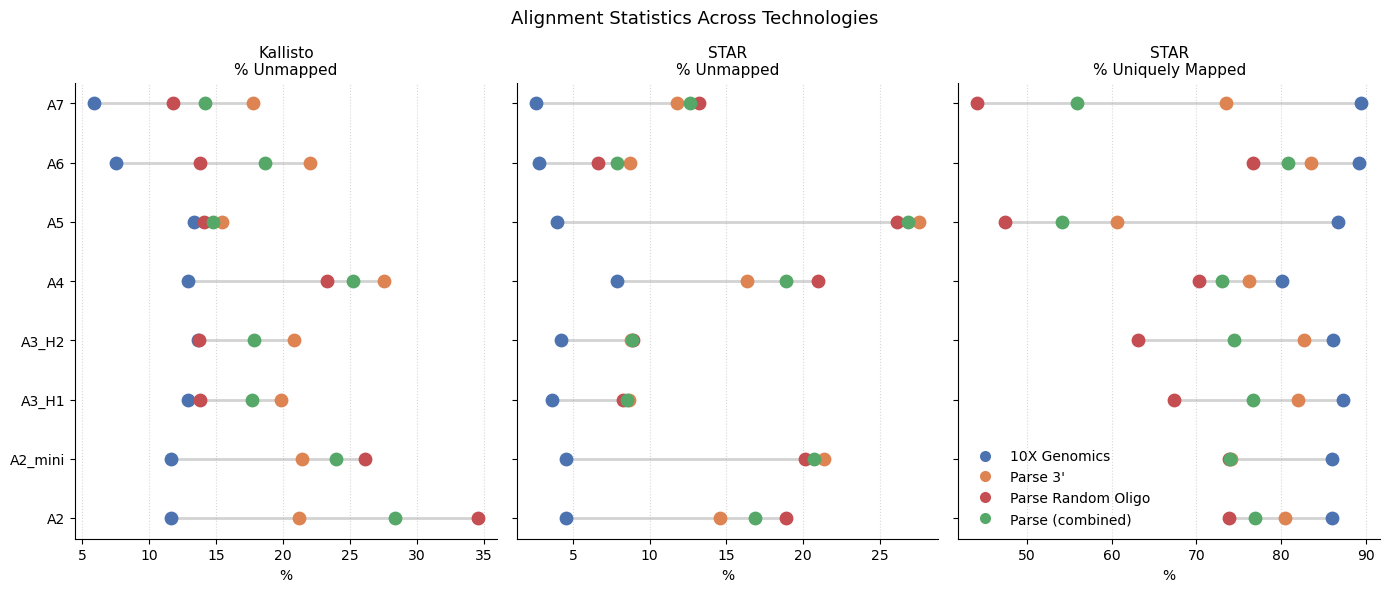

In [9]:
STAT_METRICS = [
    ('kallisto_pct_unmapped', 'Kallisto\n% Unmapped'),
    ('star_pct_unmapped',     'STAR\n% Unmapped'),
    ('star_pct_unique',       'STAR\n% Uniquely Mapped'),
]

sample_labels = [s['label'] for s in SAMPLES]

fig, axes = plt.subplots(1, len(STAT_METRICS), figsize=(14, max(4, len(sample_labels) * 0.75)), sharey=True)

for ax, (metric, title) in zip(axes, STAT_METRICS):
    for y, lbl in enumerate(sample_labels):
        sub  = stats_df[stats_df['sample'] == lbl]
        vals = {tech: sub.loc[sub['tech'] == tech, metric].values[0] for tech in TECHS}

        # Span a line from min to max to show the overall range
        ax.plot([min(vals.values()), max(vals.values())], [y, y],
                color='lightgray', linewidth=2, zorder=1)
        for tech, val in vals.items():
            ax.scatter([val], [y], color=COLORS[tech], s=80, zorder=2)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('%')
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_yticks(range(len(sample_labels)))
axes[0].set_yticklabels(sample_labels)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS[t],
               markersize=9, label=TECH_LABELS[t])
    for t in TECHS
]
axes[-1].legend(handles=legend_handles, loc='lower left', frameon=False)

fig.suptitle('Alignment Statistics Across Technologies', fontsize=13)
fig.tight_layout()
plt.show()